LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import torch
from google.colab import drive

drive.mount('/content/drive')

df_flat = pd.read_csv("/content/beyondblue_data_flattened.csv")
df_flat['text'] = df_flat['text'].astype(str).fillna("")
df_flat.head()

Mounted at /content/drive


,parent_post_id,user_id,role,text,date,category
0,1,Toby,original,"Struggling at the moment. Hello everyone, this...",2025-07-16,Anxiety
1,1,Morph,commenter,"Hi Toby, welcome and congratulations on your f...",2025-07-17,Anxiety
2,1,AudaciousPoodle,commenter,"Hi Toby, Reading your post sounds just like wh...",2025-07-17,Anxiety
3,1,_Gigi_,commenter,"Hello Toby,I'm glad you've decided to reach ou...",2025-07-18,Anxiety
4,1,Toby,op_reply,My anxiety is affecting my whole life. When I ...,2025-07-18,Anxiety


DEVICE SETUP

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


LOAD TRANSFORMER MODELS

In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax

Twitter RoBERTa SENTIMENT MODEL (3-way)

In [4]:
sentiment_model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sent_tok = AutoTokenizer.from_pretrained(sentiment_model_name, use_fast=True)
sent_model = AutoModelForSequenceClassification.from_pretrained(
    sentiment_model_name
).to(device)

# Label order for this model:
sent_labels = ["NEGATIVE", "NEUTRAL", "POSITIVE"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


English RoBERTa EMOTION MODEL

In [5]:
# Emotion model (RoBERTa LARGE)
emotion_model_name = "j-hartmann/emotion-english-roberta-large"

emo_tok = AutoTokenizer.from_pretrained(emotion_model_name, use_fast=True)
emo_model = AutoModelForSequenceClassification.from_pretrained(
    emotion_model_name
).to(device)

# Label set is the same
emo_labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

BATCH INFERENCE FUNCTION

In [6]:
def predict_dist(texts, tokenizer, model, labels, batch_size=16, max_length=512):
    all_probs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)
            logits = model(**enc).logits
            probs = softmax(logits, dim=-1).cpu().numpy()

            for p in probs:
                all_probs.append({lab: float(p[j]) for j, lab in enumerate(labels)})
    return all_probs

RUN BOTH MODELS

In [8]:
texts = df_flat["text"].tolist()

print("Running Twitter RoBERTa sentiment...")
sent_dists = predict_dist(texts, sent_tok, sent_model, sent_labels, batch_size=16)

print("Running English RoBERTa emotion...")
emo_dists = predict_dist(texts, emo_tok, emo_model, emo_labels, batch_size=8)


Running Twitter RoBERTa sentiment...
Running English RoBERTa emotion...


SENTIMENT → CONTINUOUS VALENCE

In [9]:
def valence_from_sentiment(dist):
    pos = dist.get("POSITIVE", 0.0)
    neg = dist.get("NEGATIVE", 0.0)
    return float(pos - neg)   # in [-1,1] roughly

EMOTION → Valence/Arousal using NRC-VAD

In [10]:
emo_to_va = {
    "joy":       {"val": 0.9800, "aro": 0.8240},
    "surprise":  {"val": 0.8750, "aro": 0.8750},
    "neutral":   {"val": 0.4690, "aro": 0.1840},
    "sadness":   {"val": 0.0520, "aro": 0.2880},
    "fear":      {"val": 0.0730, "aro": 0.8400},
    "anger":     {"val": 0.1670, "aro": 0.8650},
    "disgust":   {"val": 0.0520, "aro": 0.7750},
}

def va_from_emotion_dist(dist):
    if not dist:
        return 0.0, 0.5

    v = a = tot = 0.0
    for emo, p in dist.items():
        m = emo_to_va.get(emo.lower())
        if m:
            v += m["val"] * p
            a += m["aro"] * p
            tot += p

    if tot > 0:
        v /= tot
        a /= tot

    return float(v), float(a)

ADD EVERYTHING BACK TO DATAFRAME

In [11]:
df_flat["sentiment_dist"] = sent_dists
df_flat["valence_s"] = [valence_from_sentiment(d) for d in sent_dists]
df_flat["sentiment_top"] = [max(d, key=d.get) if d else None for d in sent_dists]
df_flat["sentiment_conf"] = [max(d.values()) if d else None for d in sent_dists]

df_flat["emotion_dist"] = emo_dists
va = [va_from_emotion_dist(d) for d in emo_dists]
df_flat["valence_e"], df_flat["arousal_e"] = zip(*va)
df_flat["emotion_top"] = [max(d, key=d.get) if d else None for d in emo_dists]
df_flat["emotion_conf"] = [max(d.values()) if d else None for d in emo_dists]

SAVE

In [12]:
output_path = "/content/beyondblue_data_flattened_transformers_enriched_.csv"
df_flat.to_csv(output_path, index=False)

print("Saved enriched dataset →", output_path)

Saved enriched dataset → /content/beyondblue_data_flattened_transformers_enriched_.csv


In [24]:
df_test = pd.read_csv("/content/beyondblue_data_flattened_transformers_enriched_.csv")
df_test.head()

,parent_post_id,user_id,role,text,date,category,sentiment_dist,valence_s,sentiment_top,sentiment_conf,emotion_dist,valence_e,arousal_e,emotion_top,emotion_conf
0,1,Toby,original,"Struggling at the moment. Hello everyone, this...",2025-07-16,Anxiety,"{'NEGATIVE': 0.6358407139778137, 'NEUTRAL': 0....",-0.573183,NEGATIVE,0.635841,"{'anger': 0.0030326072592288256, 'disgust': 0....",0.079505,0.828274,fear,0.969302
1,1,Morph,commenter,"Hi Toby, welcome and congratulations on your f...",2025-07-17,Anxiety,"{'NEGATIVE': 0.002651855116710067, 'NEUTRAL': ...",0.971309,POSITIVE,0.973961,"{'anger': 0.0023175962269306183, 'disgust': 0....",0.877638,0.714559,joy,0.780846
2,1,AudaciousPoodle,commenter,"Hi Toby, Reading your post sounds just like wh...",2025-07-17,Anxiety,"{'NEGATIVE': 0.7963150143623352, 'NEUTRAL': 0....",-0.754034,NEGATIVE,0.796315,"{'anger': 0.010348315350711346, 'disgust': 0.0...",0.071904,0.324703,sadness,0.913931
3,1,_Gigi_,commenter,"Hello Toby,I'm glad you've decided to reach ou...",2025-07-18,Anxiety,"{'NEGATIVE': 0.01175833772867918, 'NEUTRAL': 0...",0.903619,POSITIVE,0.915377,"{'anger': 0.0013056608149781823, 'disgust': 0....",0.867446,0.751704,joy,0.845598
4,1,Toby,op_reply,My anxiety is affecting my whole life. When I ...,2025-07-18,Anxiety,"{'NEGATIVE': 0.6501989364624023, 'NEUTRAL': 0....",-0.580363,NEGATIVE,0.650199,"{'anger': 0.010438608936965466, 'disgust': 0.0...",0.253667,0.546303,sadness,0.477066


In [13]:
import pandas as pd

# If not already loaded, load your flattened data
df_flat = pd.read_csv("/content/beyondblue_data_flattened.csv")
df_flat['text'] = df_flat['text'].astype(str).fillna("")

# Sample 50 posts for manual labeling (change 50 if you want)
val_sample = df_flat.sample(50, random_state=42)[['text']].copy()

# Add empty columns for your labels
val_sample['valence_human'] = ""   # negative / neutral / positive
val_sample['emotion_human'] = ""   # anger / disgust / fear / joy / neutral / sadness / surprise

val_path = "/content/validation_sample_for_labeling.csv"
val_sample.to_csv(val_path, index=False)

val_path

'/content/validation_sample_for_labeling.csv'

In [25]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load your labeled validation set
val_df = pd.read_csv("/content/validation_sample_labeled.csv")

val_df['text'] = val_df['text'].astype(str)

# Make sure labels are lowercase and stripped
val_df['valence_human'] = val_df['valence_human'].str.strip().str.lower()
val_df['emotion_human'] = val_df['emotion_human'].str.strip().str.lower()

Using device: cuda


In [26]:
# Twitter RoBERTa sentiment
sentiment_model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
sent_tok = AutoTokenizer.from_pretrained(sentiment_model_name, use_fast=True)
sent_model = AutoModelForSequenceClassification.from_pretrained(
    sentiment_model_name
).to(device)
sent_labels = ["NEGATIVE", "NEUTRAL", "POSITIVE"]

# Emotion model (RoBERTa LARGE)
emotion_model_name = "j-hartmann/emotion-english-roberta-large"

emo_tok = AutoTokenizer.from_pretrained(emotion_model_name, use_fast=True)
emo_model = AutoModelForSequenceClassification.from_pretrained(
    emotion_model_name
).to(device)

# Label set is the same
emo_labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [27]:
def predict_sentiment_label(text):
    enc = sent_tok(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)
    with torch.no_grad():
        logits = sent_model(**enc).logits
        probs = softmax(logits, dim=-1)[0].cpu().numpy()
    idx = probs.argmax()
    return sent_labels[idx].lower()   # -> "negative"/"neutral"/"positive"


def predict_emotion_label(text):
    enc = emo_tok(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)
    with torch.no_grad():
        logits = emo_model(**enc).logits
        probs = softmax(logits, dim=-1)[0].cpu().numpy()
    idx = probs.argmax()
    return emo_labels[idx].lower()

In [28]:
val_df['valence_model'] = val_df['text'].apply(predict_sentiment_label)
val_df['emotion_model'] = val_df['text'].apply(predict_emotion_label)

val_df[['text','valence_human','valence_model','emotion_human','emotion_model']].head(50)

,text,valence_human,valence_model,emotion_human,emotion_model
0,"PTSD,Fear and abdominal problems. Hi i am a 8...",negative,negative,fear,fear
1,"Hello Dear soonie1, A very warm welcome to our...",positive,negative,joy,sadness
2,New job opportunity anxiety. I work at a schoo...,negative,negative,fear,fear
3,"My brother grew up with milk allergies, but .....",negative,negative,anger,sadness
4,"Hi, I totally get how you feel. I'm about ti m...",neutral,neutral,joy,joy
5,Physical symptoms anxiety. I have recently gon...,negative,negative,fear,fear
6,"Hi mchops, I am in a similar boat to you excep...",negative,negative,sadness,fear
7,Hi Atleigh. I think it's brave that you tried ...,neutral,neutral,neutral,neutral
8,"Dear anna630,If you can identify that you are ...",negative,neutral,fear,fear
9,"Thank you Thorney, I do journal. I didn’t like...",positive,neutral,joy,fear


In [ ]:
!pip install scikit-learn --quiet

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---- Sentiment (valence) ----
sent_acc = accuracy_score(val_df['valence_human'], val_df['valence_model'])
print("Sentiment agreement (human vs model):", sent_acc)

print("\nSentiment confusion matrix:\n")
print(confusion_matrix(val_df['valence_human'], val_df['valence_model'], labels=["negative","neutral","positive"]))

print("\nSentiment classification report:\n")
print(classification_report(val_df['valence_human'], val_df['valence_model'], labels=["negative","neutral","positive"]))


# ---- Emotion ----
emo_acc = accuracy_score(val_df['emotion_human'], val_df['emotion_model'])
print("Emotion agreement (human vs model):", emo_acc)

print("\nEmotion confusion matrix:\n")
print(confusion_matrix(val_df['emotion_human'], val_df['emotion_model'], labels=emo_labels))

print("\nEmotion classification report:\n")
print(classification_report(val_df['emotion_human'], val_df['emotion_model'], labels=emo_labels))

Sentiment agreement (human vs model): 0.76

Sentiment confusion matrix:

[[19  3  0]
 [ 2 10  0]
 [ 5  2  9]]

Sentiment classification report:

              precision    recall  f1-score   support

    negative       0.73      0.86      0.79        22
     neutral       0.67      0.83      0.74        12
    positive       1.00      0.56      0.72        16

    accuracy                           0.76        50
   macro avg       0.80      0.75      0.75        50
weighted avg       0.80      0.76      0.76        50

Emotion agreement (human vs model): 0.7

Emotion confusion matrix:

[[ 0  0  1  0  0  1  0]
 [ 0  2  0  0  0  0  0]
 [ 0  0 14  0  1  0  1]
 [ 0  0  4  5  3  2  0]
 [ 0  0  0  0  5  1  0]
 [ 0  0  1  0  0  8  0]
 [ 0  0  0  0  0  0  1]]

Emotion classification report:

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00         2
     disgust       1.00      1.00      1.00         2
        fear       0.70      0.88      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


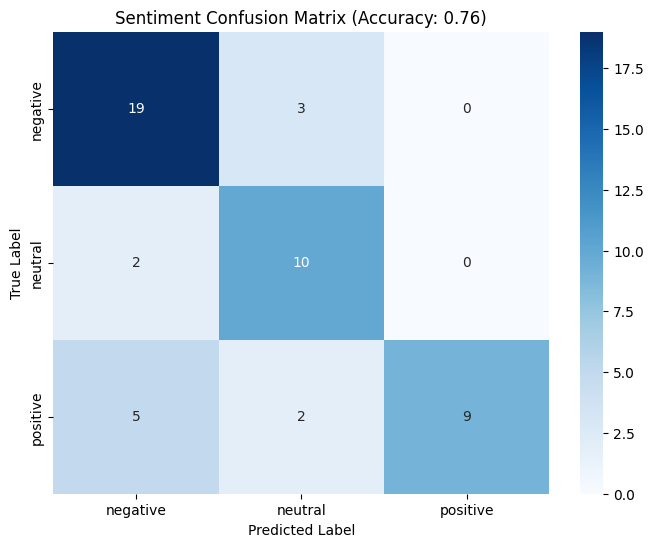

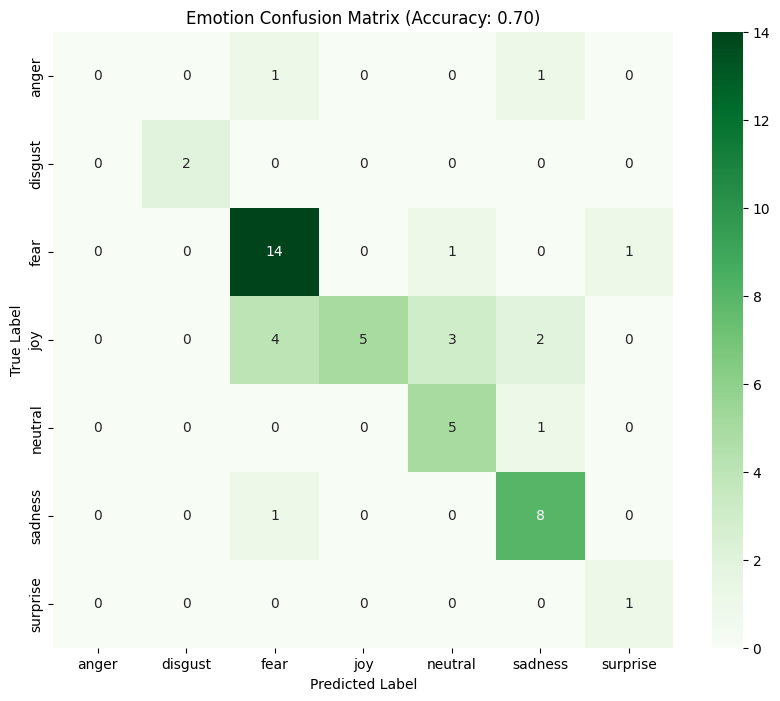

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Sentiment (valence) Confusion Matrix
sent_cm = confusion_matrix(val_df['valence_human'], val_df['valence_model'], labels=["negative","neutral","positive"])
plt.figure(figsize=(8, 6))
sns.heatmap(sent_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["negative","neutral","positive"], yticklabels=["negative","neutral","positive"])
plt.title(f'Sentiment Confusion Matrix (Accuracy: {sent_acc:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Emotion Confusion Matrix
emo_cm = confusion_matrix(val_df['emotion_human'], val_df['emotion_model'], labels=emo_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(emo_cm, annot=True, fmt="d", cmap="Greens", xticklabels=emo_labels, yticklabels=emo_labels)
plt.title(f'Emotion Confusion Matrix (Accuracy: {emo_acc:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [32]:
# Cases where sentiment disagrees
val_df[val_df['valence_human'] != val_df['valence_model']][
    ['text','valence_human','valence_model']
].head(10)

# Cases where emotion disagrees
val_df[val_df['emotion_human'] != val_df['emotion_model']][
    ['text','emotion_human','emotion_model']
].head(10)

,text,emotion_human,emotion_model
1,"Hello Dear soonie1, A very warm welcome to our...",joy,sadness
3,"My brother grew up with milk allergies, but .....",anger,sadness
6,"Hi mchops, I am in a similar boat to you excep...",sadness,fear
9,"Thank you Thorney, I do journal. I didn’t like...",joy,fear
16,Thank you therising for giving some insight in...,neutral,sadness
17,Hmmm hey bigaloohope you are doing better toda...,joy,sadness
21,Hi Guest Warm welcome to the forum and I'm so ...,joy,fear
25,Thank you for your reply. I’m sure of my decis...,joy,neutral
29,"Thanks Geoff and Billie, My psychologist aske...",fear,neutral
36,In was completely terrified about my test I th...,joy,fear
